In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Customer Segmentation

This notebook segments 300 customers based on their purchase behavior (RFM: Recency, Frequency, Monetary), using K-Means clustering, and assigns each resulting cluster a business persona.

## RFM Feature Table

We start from the raw transaction-level dataset and build a customer-level RFM table.

In [5]:
df = pd.read_csv('retail_transactions_segmentation.csv')
df.head()

,customer_id,transaction_date,amount,product_category
0,5206,2024-01-31,162.65,Fashion
1,5153,2024-07-03,389.85,Fashion
2,5102,2024-11-13,453.72,Home & Living
3,5073,2024-03-11,824.74,Electronics
4,5097,2024-12-28,181.74,Sports


In [6]:
df.shape

(3663, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3663 entries, 0 to 3662
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       3663 non-null   int64  
 1   transaction_date  3663 non-null   object 
 2   amount            3663 non-null   float64
 3   product_category  3663 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 114.6+ KB


**Building the RFM table**

- **Reference date used for Recency:** the maximum `transaction_date` found in the dataset (i.e. the most recent transaction date across all customers).
- **Monetary:** total spend per customer (sum of `amount`), not the average.
- **Frequency:** number of transactions per customer.

We group the raw transactions by `customer_id` to collapse the 3,663 transaction rows into a 300-row, customer-level table.

In [13]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
reference_date = df['transaction_date'].max()

rfm = df.groupby('customer_id').agg(
    Recency=('transaction_date', lambda x: (reference_date - x.max()).days),
    Frequency=('transaction_date', 'count'),
    Monetary=('amount', 'sum')
).reset_index()

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,5001,1,16,5172.45
1,5002,22,18,6158.98
2,5003,36,3,654.12
3,5004,4,35,31050.88
4,5005,25,16,5700.91


In [15]:
rfm.shape

(300, 4)

## Feature Scaling

Recency (days), Frequency (transaction counts), and Monetary (currency) are on completely different numeric scales — Monetary values run into the thousands while Frequency is a small integer. Without scaling, K-Means (which relies on Euclidean distance) would let Monetary dominate the clustering and effectively ignore Recency and Frequency. We standardize all three features before clustering.

In [18]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled[:5]

array([[-0.77279216,  0.35669228, -0.11319594],
       [-0.46463401,  0.5449204 , -0.01089795],
       [-0.25919524, -0.86679048, -0.58172306],
       [-0.72876957,  2.1448594 ,  2.57026153],
       [-0.42061142,  0.35669228, -0.05839741]])

##  Choosing k (Elbow Method + Silhouette Score)

We evaluate k from 2 to 10 using two methods: the elbow method (inertia) and the silhouette score, and plot both to justify our choice of k.

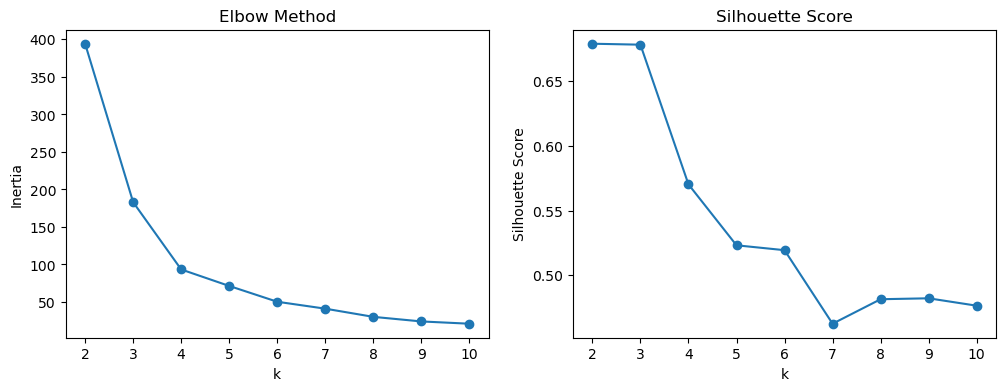

In [21]:

inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(k_range, inertias, marker='o')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Inertia')
ax[0].set_title('Elbow Method')

ax[1].plot(k_range, silhouettes, marker='o')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_title('Silhouette Score')

plt.show()

**Choice of k: we selected k = 4.**

The elbow plot shows inertia dropping sharply up to around k = 3–4 and then flattening, suggesting little additional benefit from more clusters beyond that point. The silhouette score is highest at k = 2 (0.66) and k = 3 (0.655), then drops noticeably at k = 4 (~0.565). We chose k = 4 over the marginally higher-scoring k = 3 because it splits the largest, over-generalized group from the k = 3 solution (238 customers) into two more evenly sized, more distinguishable segments (128 and 111 customers), producing more actionable business personas without a large loss in cluster separation quality.

##  K-Means Clustering

We fit K-Means on the scaled RFM features using k = 4, with a fixed `random_state` for reproducibility, and attach the resulting cluster label back onto each customer.

In [25]:
k_final = 4

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

rfm.head()

,customer_id,Recency,Frequency,Monetary,Cluster
0,5001,1,16,5172.45,3
1,5002,22,18,6158.98,3
2,5003,36,3,654.12,0
3,5004,4,35,31050.88,1
4,5005,25,16,5700.91,3


In [27]:
rfm['Cluster'].value_counts()

Cluster
3    128
0    111
1     40
2     21
Name: count, dtype: int64

##  PCA Visualization

We reduce the three scaled RFM features to 2 principal components with PCA, so the four clusters can be inspected visually.

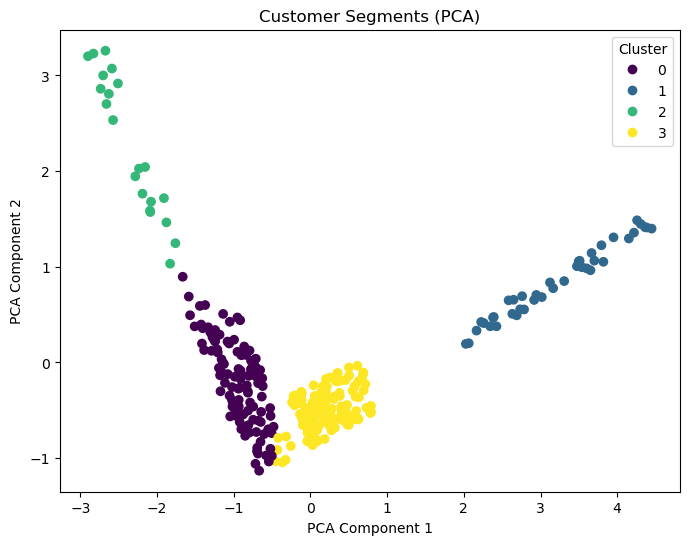

In [30]:


pca = PCA(n_components=2)
pca_result = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(pca_result[:,0], pca_result[:,1], c=rfm['Cluster'], cmap='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segments (PCA)')
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

## P Named Personas

Mean Recency, Frequency, and Monetary per cluster — the evidence behind each persona name below.

In [33]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,70.567568,4.225225,752.488739
1,7.400000,35.000000,29683.612250
2,262.380952,2.095238,320.479048
3,19.218750,13.671875,4700.172969


In [35]:
best_cluster = cluster_summary.sort_values('Monetary', ascending=False)
best_cluster

,Recency,Frequency,Monetary
Cluster,,,
1,7.400000,35.000000,29683.612250
3,19.218750,13.671875,4700.172969
0,70.567568,4.225225,752.488739
2,262.380952,2.095238,320.479048


### Persona Summary

**Cluster 1 — VIP (40 customers)**
Your best customers. They bought recently (7.4 days on average), buy often (35 transactions), and spend the most by far (29,684 total). Keep them happy with loyalty perks and early access to offers.

**Cluster 3 — At-risk (128 customers)**
Solid, steady customers who buy fairly often (13.7 transactions, last purchase 19 days ago) and spend a decent amount (~4,700). Push them toward VIP status with upsell offers.

**Cluster 0 — Occasional (111 customers)**
Customers who buy rarely (4.2 transactions, last purchase ~70 days ago) and spend little (752). They need a nudge — discounts or reminder emails to bring them back.

**Cluster 2 — Dormant (21 customers)**
Haven't bought in a long time (~262 days) and barely spend anything (320, 2.1 transactions). Not worth heavy investment — try one cheap "win-back" offer to see if they respond.